# BayesFlow + SIR Inference + R0 Posterior

1. simulate noisy infected-fraction trajectories from an SIR model,
2. train a BayesFlow posterior estimator for `beta` and `gamma`,
3. derive the posterior of `R0 = beta / gamma`,
4. visualize and interpret the posterior results.

## VSCode + Colab Setup

In [1]:

# %pip install -q bayesflow==2.0.9 numpy==1.26.4 pandas==2.3.3 scipy==1.15.3 matplotlib==3.8.4 seaborn

In [2]:
import os
import warnings
from importlib import metadata


# 检查版本并设置环境变量
warnings.filterwarnings("ignore")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp

try:
    import tensorflow as tf
    import keras
    import bayesflow as bf
except Exception as e:
    raise RuntimeError(
        "Import failed. If you just ran the %pip install cell in VS Code or Colab, please restart the kernel and then rerun this cell. Original error: "
        + repr(e)
    )

expected_versions = {
    "bayesflow": "2.0.9",
    "tensorflow": "2.17.0",
    "keras": "3.13.2",
    "numpy": "1.26.4",
    "pandas": "2.3.3",
    "scipy": "1.15.3",
    "matplotlib": "3.8.4",
}

for pkg, expected in expected_versions.items():
    current = metadata.version(pkg)
    print(f"{pkg}: {current}")
    if current != expected:
        print(f"  warning: expected {expected}, but found {current}")

np.random.seed(42)
keras.utils.set_random_seed(42)
sns.set_theme(style="whitegrid", context="notebook")

print("BayesFlow backend ready.")

INFO:bayesflow:Using backend 'tensorflow'


bayesflow: 2.0.9
tensorflow: 2.17.0
keras: 3.13.2
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.15.3
matplotlib: 3.8.4
BayesFlow backend ready.


## SIR 模型设定

- Unknown parameters: `beta`, `gamma`
- Derived quantity: `R0 = beta / gamma`
- Observation: noisy infected-fraction time series
- Summary network: `time_series_network`
- Inference network: `coupling_flow`

## BayesFlow Workflow

这一部分把 `simulator` 接到 BayesFlow 2.x 中，并定义 posterior inference 所需的 workflow、summary network 和 inference network。

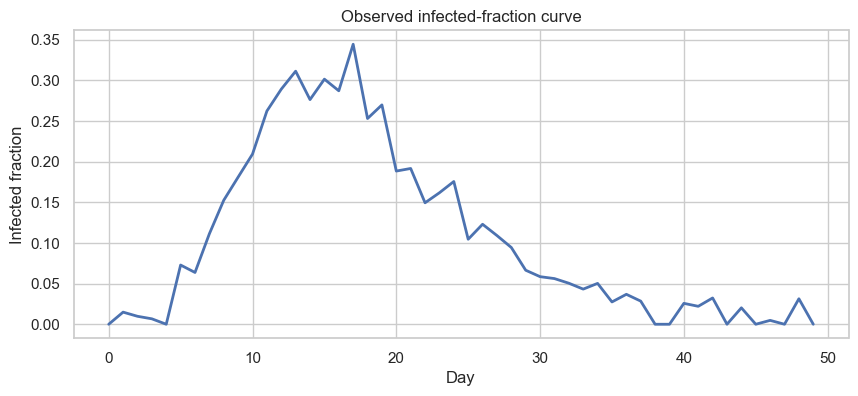

True beta: 0.55
True gamma: 0.18
True R0: 3.056


In [3]:
N_DAYS = 50
TIME_GRID = np.arange(N_DAYS)
I0 = 0.01
R0_INIT = 0.0
S0 = 1.0 - I0 - R0_INIT
OBS_NOISE = 0.02

PRIOR_BOUNDS = {
    "beta": (0.10, 1.00),
    "gamma": (0.05, 0.50),
}
TRAIN_RNG = np.random.default_rng(42)

EPS = 1e-6

def to_unconstrained(x, low, high):
    """
    Map x in (low, high) to real line via scaled logit transform.
    """
    u = (x - low) / (high - low)
    u = np.clip(u, EPS, 1.0 - EPS)
    return np.log(u / (1.0 - u))


def from_unconstrained(z, low, high):
    """
    Map real line back to (low, high) via scaled sigmoid transform.
    """
    s = 1.0 / (1.0 + np.exp(-z))
    return low + (high - low) * s


def sir_rhs(t, y, beta, gamma):
    s, i, r = y
    ds = -beta * s * i
    di = beta * s * i - gamma * i
    dr = gamma * i
    return [ds, di, dr]


def solve_sir(beta, gamma, n_days=N_DAYS):
    sol = solve_ivp(
        lambda t, y: sir_rhs(t, y, beta, gamma),
        (0, n_days - 1),
        [S0, I0, R0_INIT],
        t_eval=np.arange(n_days),
        rtol=1e-6,
        atol=1e-8,
    )
    return sol.y.T


def simulate_curve(beta, gamma, rng=None):
    infected = solve_sir(beta, gamma)[:, 1]

    if rng is None:
        noise = np.random.normal(0.0, OBS_NOISE, size=infected.shape)
    else:
        noise = rng.normal(0.0, OBS_NOISE, size=infected.shape)

    obs = infected + noise
    obs = np.clip(obs, 0.0, 1.0)
    return obs[:, None].astype("float32")


def sim_one():
    beta = TRAIN_RNG.uniform(*PRIOR_BOUNDS["beta"])
    gamma = TRAIN_RNG.uniform(*PRIOR_BOUNDS["gamma"])

    z_beta = to_unconstrained(beta, *PRIOR_BOUNDS["beta"])
    z_gamma = to_unconstrained(gamma, *PRIOR_BOUNDS["gamma"])

    return {
        "z_beta": np.array([z_beta], dtype="float32"),
        "z_gamma": np.array([z_gamma], dtype="float32"),
        "obs": simulate_curve(beta, gamma, rng=TRAIN_RNG),
    }


true_beta = 0.55
true_gamma = 0.18
true_r0 = true_beta / true_gamma
single_case_rng = np.random.default_rng(2025)
observed_curve = simulate_curve(true_beta, true_gamma, rng=single_case_rng)

plt.figure(figsize=(10, 4))
plt.plot(TIME_GRID, observed_curve[:, 0], lw=2)
plt.xlabel("Day")
plt.ylabel("Infected fraction")
plt.title("Observed infected-fraction curve")
plt.show()

print("True beta:", true_beta)
print("True gamma:", true_gamma)
print("True R0:", round(true_r0, 3))

First, to respect the bounded support of epidemiological parameters, we infer unconstrained transformed variables and map posterior samples back to the original parameter space via an inverse sigmoid transform.

图1展示了 E0 matched baseline 中的一个single case观测序列。我们首先使用 SIR 动力学在给定真值参数 `beta = 0.55`、`gamma = 0.18` 下生成 latent infected-fraction trajectory，然后加入标准差为 `0.02` 的 Gaussian observation noise，并将结果裁剪到合法区间 `[0, 1]`，从而得到最终的 observed infected-fraction curve。由于 `R0 = beta / gamma = 3.056 > 1`，感染比例在早期快速上升，并在中期达到峰值，之后随着易感者耗竭和恢复累积而逐渐下降。图中的局部波动主要来自观测噪声，因此该曲线是 noisy replicated observation。

In [4]:
simulator = bf.make_simulator(sim_one)

workflow = bf.BasicWorkflow(
    simulator=simulator,
    inference_variables=["z_beta", "z_gamma"],
    summary_variables=["obs"],
    summary_network="time_series_network",
    inference_network="coupling_flow",
)

workflow.approximator.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4)
)

print("BayesFlow workflow ready.")

BayesFlow workflow ready.


## 训练 posterior estimator

这一部分使用模拟数据训练 BayesFlow 的 amortized posterior，使模型能够从观测曲线直接推断 `beta` 和 `gamma`。

INFO:bayesflow:Building dataset from simulator instance of LambdaSimulator.
INFO:bayesflow:Building on a test batch.


Epoch 1/12
60/60 - 11s - 181ms/step - loss: 2.4911
Epoch 2/12
60/60 - 3s - 50ms/step - loss: 1.4776
Epoch 3/12
60/60 - 3s - 55ms/step - loss: 0.7338
Epoch 4/12
60/60 - 3s - 54ms/step - loss: 0.0469
Epoch 5/12
60/60 - 3s - 57ms/step - loss: -1.9847e-02
Epoch 6/12
60/60 - 3s - 54ms/step - loss: -4.1947e-01
Epoch 7/12
60/60 - 3s - 54ms/step - loss: -5.5080e-01
Epoch 8/12
60/60 - 3s - 55ms/step - loss: -4.7803e-01
Epoch 9/12
60/60 - 3s - 55ms/step - loss: -8.6912e-01
Epoch 10/12
60/60 - 3s - 55ms/step - loss: -7.8531e-01
Epoch 11/12
60/60 - 3s - 55ms/step - loss: -9.1669e-01
Epoch 12/12
60/60 - 3s - 55ms/step - loss: -8.4954e-01


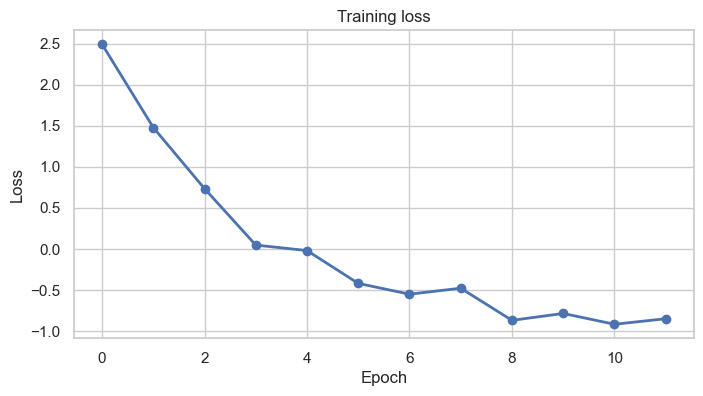

In [5]:
# Increase epochs and num_batches if you want a tighter posterior.
history = workflow.approximator.fit(
    simulator=simulator,
    epochs=12,
    batch_size=32,
    num_batches=60,
    workers=1,
    verbose=2,
)

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], marker="o", lw=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

图2展示了 BayesFlow posterior estimator 在 matched SIR-to-SIR baseline 下的训练 loss。训练过程中，模型通过在线模拟不断生成新的 `(obs, z_beta, z_gamma)` 样本，并学习从 noisy infected-fraction time series 到参数后验的 amortized inference rule。我们可以看到，loss 在前几个 epoch 内快速下降，说明模型较快捕捉到了观测曲线形状与潜在参数之间的主要对应关系；之后 loss 继续下降并在后期进入轻微波动的平台区间。总的来说，loss 曲线没有出现发散或持续回升，说明我们的训练过程稳定，并为后续的 posterior recovery、coverage 和 PPC 结果提供了基础。

## 后验采样与 R0 推断

这一部分在给定观测曲线后，从 posterior 中采样参数，并进一步计算 `R0 = beta / gamma` 的后验统计量。

In [6]:
samples = workflow.sample(
    num_samples=4000,
    conditions={"obs": observed_curve[None, ...]},
    split=True,
    batch_size=1,
)

z_beta_samps = np.asarray(samples["z_beta"]).reshape(-1)
z_gamma_samps = np.asarray(samples["z_gamma"]).reshape(-1)

beta_samps = from_unconstrained(z_beta_samps, *PRIOR_BOUNDS["beta"])
gamma_samps = from_unconstrained(z_gamma_samps, *PRIOR_BOUNDS["gamma"])

posterior_df = pd.DataFrame({
    "beta": beta_samps,
    "gamma": gamma_samps,
})
posterior_df["R0"] = posterior_df["beta"] / posterior_df["gamma"]

summary_table = posterior_df[["beta", "gamma", "R0"]].describe(percentiles=[0.05, 0.5, 0.95]).T
summary_table = summary_table[["mean", "std", "5%", "50%", "95%"]]
summary_table

Sampling: 100%|██████████| 1/1 [00:00<00:00, 14.66batch/s]
INFO:bayesflow:Sampling completed in 0.29 seconds.


,mean,std,5%,50%,95%
beta,0.538153,0.012792,0.516809,0.538200,0.559293
gamma,0.180431,0.005996,0.170929,0.180224,0.190554
R0,2.985118,0.101628,2.818640,2.983993,3.157492


给定观测曲线后，我们从训练好的 BayesFlow posterior 中抽取 4000 个后验样本，并将 transformed variables `z_beta` 和 `z_gamma` 反变换回原始参数空间。然后，我们逐样本计算 derived quantity `R0 = beta / gamma`，从而得到 `beta`、`gamma` 和 `R0` 的联合后验汇总。结果表明，`beta` 的 posterior 中心约为 `0.538`，`gamma` 的 posterior 中心约为 `0.180`，而 `R0` 的 posterior 中心约为 `2.984`。三者的真值均落在 90% posterior interval 内，说明该 matched baseline 在单案例上能够较好恢复参数及其派生流行病学量。特别是，`R0` 的后验明显大于 1，表明模型正确识别了该观测序列对应于一个处于扩张阶段的 epidemic regime。

## 可视化与 posterior predictive check

这一部分负责展示 `beta`、`gamma`、`R0` 的后验分布，观察参数相关性，并检查 posterior predictive trajectories 是否能够覆盖观测曲线。

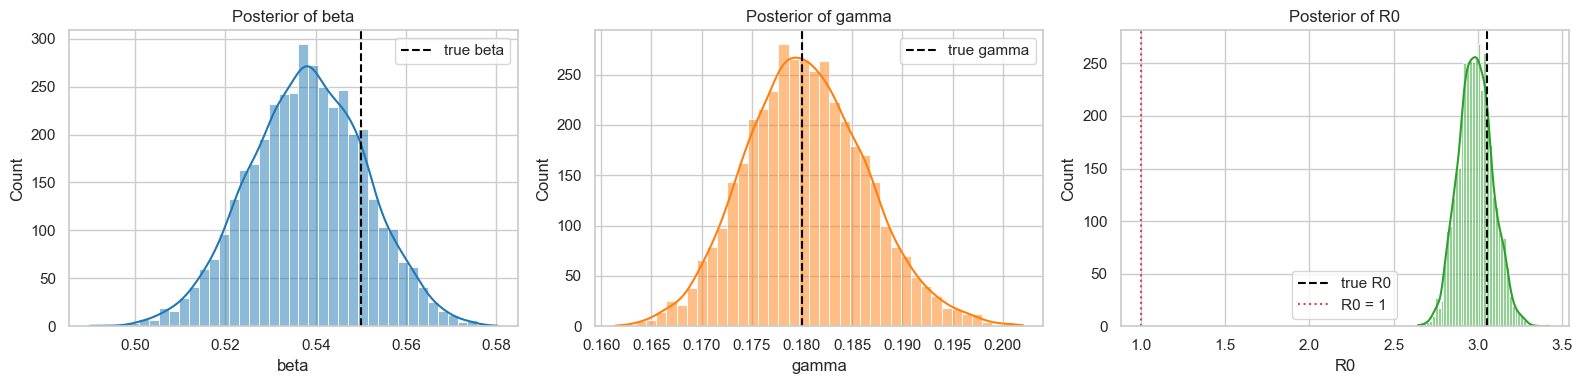

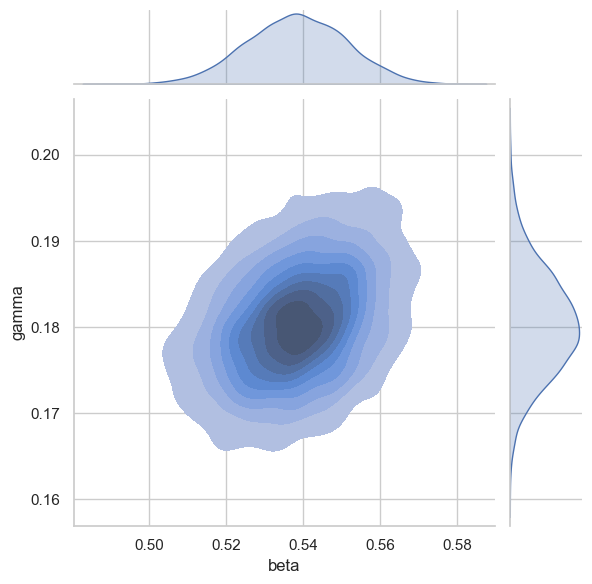

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(posterior_df["beta"], kde=True, ax=axes[0], color="#1f77b4")
axes[0].axvline(true_beta, color="black", linestyle="--", label="true beta")
axes[0].set_title("Posterior of beta")
axes[0].legend()

sns.histplot(posterior_df["gamma"], kde=True, ax=axes[1], color="#ff7f0e")
axes[1].axvline(true_gamma, color="black", linestyle="--", label="true gamma")
axes[1].set_title("Posterior of gamma")
axes[1].legend()

sns.histplot(posterior_df["R0"], kde=True, ax=axes[2], color="#2ca02c")
axes[2].axvline(true_r0, color="black", linestyle="--", label="true R0")
axes[2].axvline(1.0, color="#c44e52", linestyle=":", label="R0 = 1")
axes[2].set_title("Posterior of R0")
axes[2].legend()

plt.tight_layout()
plt.show()

sns.jointplot(data=posterior_df, x="beta", y="gamma", kind="kde", fill=True)
plt.show()

这几张图展示了单案例下 `beta`、`gamma` 和 derived quantity `R0` 的边缘后验分布，以及 `beta–gamma` 的联合后验结构。我们可以看到，三个边缘后验均呈现单峰且较为平滑的分布形状，说明在 matched SIR-to-SIR baseline 下，给定该观测曲线后，模型得到的是稳定且集中的后验，而不是多峰或异常长尾的近似。`beta` 的后验中心略低于真值 `0.55`，但真值仍位于高密度区域内；`gamma` 的后验中心则与真值 `0.18` 非常接近。`R0` 的后验几乎完全位于 `1` 以上，表明模型明确支持该案例处于扩张型 epidemic regime，而不是衰退阶段。联合后验图进一步显示 `beta` 与 `gamma` 存在一定正相关，说明不同的传播率与恢复率组合可以在一定程度上共同解释相似的观测曲线形状。

In [8]:
r0_ci = np.quantile(posterior_df["R0"], [0.05, 0.5, 0.95])
prob_r0_gt_1 = float((posterior_df["R0"] > 1.0).mean())

print(f"True R0: {true_r0:.3f}")
print(f"Posterior median R0: {r0_ci[1]:.3f}")
print(f"Posterior 90% interval for R0: [{r0_ci[0]:.3f}, {r0_ci[2]:.3f}]")
print(f"Posterior probability R0 > 1: {prob_r0_gt_1:.4f}")

True R0: 3.056
Posterior median R0: 2.984
Posterior 90% interval for R0: [2.819, 3.157]
Posterior probability R0 > 1: 1.0000


为了进一步将参数后验转化为流行病学解释，我们基于 posterior samples 逐样本计算 `R0 = beta / gamma`，并报告其中位数、90% posterior interval，以及 `P(R0 > 1)`。结果表明，该案例的 posterior median `R0` 约为 `2.984`，90% posterior interval 为 `[2.819, 3.157]`，真实值 `3.056` 落在该区间内。更重要的是，posterior probability `P(R0 > 1)` 为 `1.0000`，说明在该观测曲线下，模型几乎确定地支持一个 supercritical epidemic regime。这与观测曲线在早期表现出的明显增长趋势一致，也表明 matched baseline 不仅能够恢复参数数值, but also at providing the correct epidemiological interpretation through a derived posterior quantity.

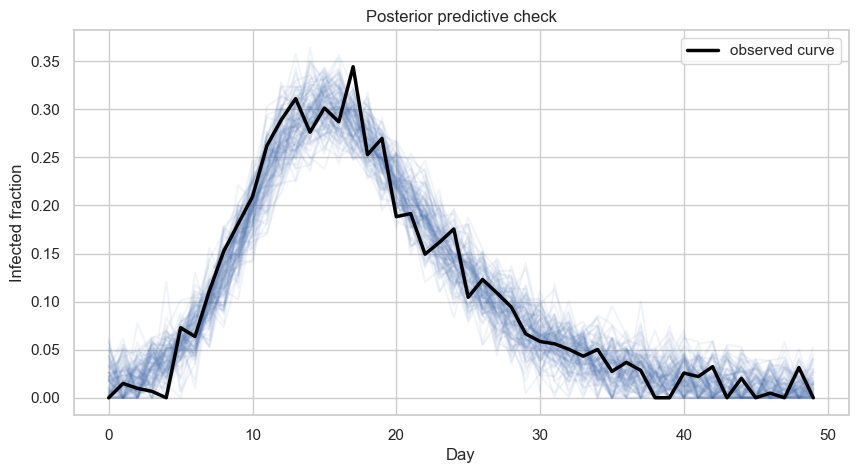

In [9]:
n_ppc = 100
single_ppc_rng = np.random.default_rng(2024)
draw_ids = single_ppc_rng.choice(len(posterior_df), size=n_ppc, replace=False)
ppc_draws = posterior_df.iloc[draw_ids][["beta", "gamma"]].to_numpy()
ppc_curves = np.stack(
    [simulate_curve(beta, gamma, rng=single_ppc_rng)[:, 0] for beta, gamma in ppc_draws],
    axis=0,
)

plt.figure(figsize=(10, 5))
for curve in ppc_curves:
    plt.plot(TIME_GRID, curve, color="#4c72b0", alpha=0.08)
plt.plot(TIME_GRID, observed_curve[:, 0], color="black", lw=2.5, label="observed curve")
plt.xlabel("Day")
plt.ylabel("Infected fraction")
plt.title("Posterior predictive check")
plt.legend()
plt.show()

这张图图展示的是single case下的 posterior predictive check。我们首先从单案例 posterior 中抽取 100 组 `(beta, gamma)` 样本，然后在每组参数下重新生成 noisy infected-fraction observation，并将这些 replicated curves 与原始观测曲线叠加比较。可以看到，posterior predictive curves 整体复现了观测曲线的主要结构，包括早期增长、中期峰值和后期衰减，同时在峰值位置、峰值高度和尾部衰减幅度上都与观测曲线保持一致。虽然单条 replicated curve 不会逐点贴合观测曲线，但黑色观测曲线总体位于 posterior predictive cloud 的高密度区域内，说明当前 posterior 在数据空间中也是合理的。需要注意的是，这里的 PPC 比较对象是带噪的 replicated observations，而不是无噪声 latent epidemic trajectories，因此图中的局部抖动和尾部贴近 0 的现象都属于 observation model 的自然结果。

## Batch matched baseline evaluation


Sampling: 100%|██████████| 1/1 [00:00<00:00, 20.77batch/s]
INFO:bayesflow:Sampling completed in 0.23 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 22.21batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 22.17batch/s]
INFO:bayesflow:Sampling completed in 0.18 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 21.92batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 20.96batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 23.08batch/s]
INFO:bayesflow:Sampling completed in 0.18 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 22.71batch/s]
INFO:bayesflow:Sampling completed in 0.18 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 22.02batch/s]
INFO:bayesflow:Sampling completed in 0.18 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 14.67batch/s]
INFO:bayesflow:Sampling completed in 0.22 seconds.
Sampling: 


Per-case summary head:


,case_id,true_beta,true_gamma,true_R0,beta_mean,beta_median,beta_std,beta_ci50_low,beta_ci50_high,beta_ci90_low,...,gamma_err_mean,gamma_err_median,gamma_abs_err_median,gamma_sq_err_median,R0_covered50,R0_covered90,R0_err_mean,R0_err_median,R0_abs_err_median,R0_sq_err_median
0,0,0.261041,0.337961,0.772401,0.149366,0.117901,0.077242,0.103887,0.159933,0.100163,...,-0.134880,-0.169698,0.169698,0.028797,1.0,1.0,0.167262,0.084806,0.084806,0.007192
1,1,0.708075,0.309730,2.286106,0.698493,0.698791,0.018755,0.686153,0.711835,0.667156,...,0.016218,0.016005,0.016005,0.000256,0.0,0.0,-0.141426,-0.143886,0.143886,0.020703
2,2,0.404338,0.350867,1.152396,0.385337,0.381784,0.106043,0.306842,0.461634,0.215229,...,0.018983,0.036228,0.036228,0.001312,1.0,1.0,-0.086940,-0.091420,0.091420,0.008358
3,3,0.803229,0.214378,3.746785,0.799761,0.800627,0.024142,0.783306,0.816561,0.758571,...,-0.002577,-0.002736,0.002736,0.000007,1.0,1.0,0.034306,0.023821,0.023821,0.000567
4,4,0.543643,0.336812,1.614083,0.481789,0.481110,0.021385,0.467068,0.495480,0.446983,...,-0.027308,-0.027301,0.027301,0.000745,0.0,1.0,-0.054664,-0.057593,0.057593,0.003317



Recovery summary:


,quantity,bias_mean_est,bias_median_est,MAE_median_est,RMSE_median_est,corr_truth_vs_median,avg_post_std
0,beta,-0.0106,-0.0188,0.0400,0.0670,0.9687,0.0533
1,gamma,-0.0042,-0.0003,0.0370,0.0702,0.8458,0.0435
2,R0,-0.0395,-0.0535,0.1428,0.1984,0.9978,0.2525



Coverage summary:


,quantity,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,avg_width50,avg_width90
0,beta,0.5,0.52,0.02,0.9,0.89,-0.01,0.0689,0.1701
1,gamma,0.5,0.54,0.04,0.9,0.91,0.01,0.0685,0.1367
2,R0,0.5,0.61,0.11,0.9,0.96,0.06,0.3399,0.8199


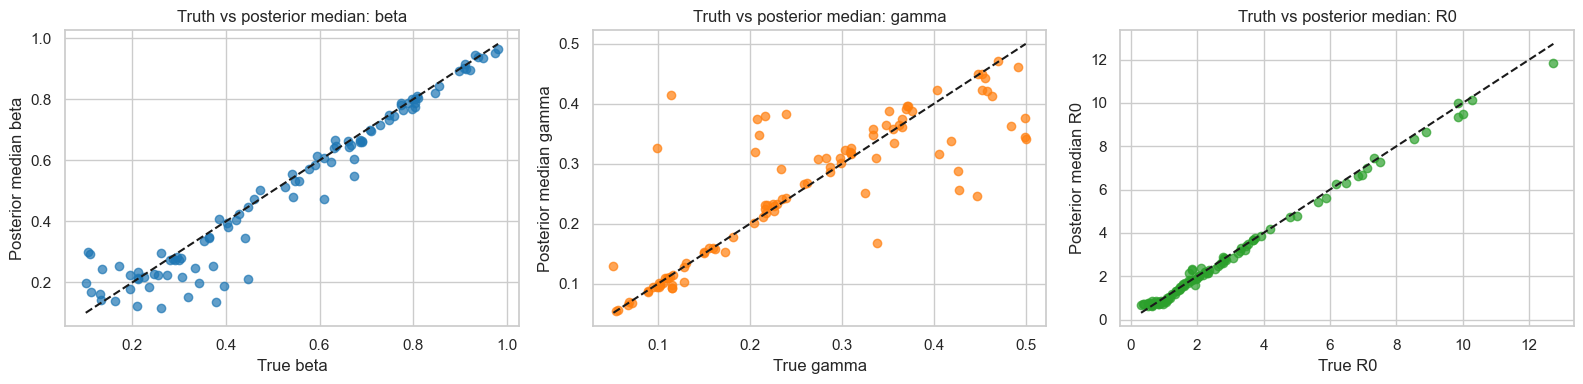

Saved:
  outputs_baseline/E0_matched_case_level.csv
  outputs_baseline/E0_matched_recovery_summary.csv
  outputs_baseline/E0_matched_coverage_summary.csv


In [10]:
def simulate_case(beta=None, gamma=None, rng=None):
    """Generate one matched SIR test case with truth + noisy observation."""
    if rng is None:
        rng = np.random.default_rng()

    if beta is None:
        beta = rng.uniform(*PRIOR_BOUNDS["beta"])
    if gamma is None:
        gamma = rng.uniform(*PRIOR_BOUNDS["gamma"])

    obs = simulate_curve(beta, gamma, rng=rng)
    return {
        "true_beta": float(beta),
        "true_gamma": float(gamma),
        "true_R0": float(beta / gamma),
        "obs": obs,
    }

def summarize_posterior_samples(beta_samples, gamma_samples):
    """Return posterior summaries for beta, gamma, and derived R0."""
    beta_samples = np.asarray(beta_samples).reshape(-1)
    gamma_samples = np.asarray(gamma_samples).reshape(-1)
    r0_samples = beta_samples / gamma_samples

    out = {}
    for name, arr in [("beta", beta_samples), ("gamma", gamma_samples), ("R0", r0_samples)]:
        q25, q50, q75 = np.quantile(arr, [0.25, 0.50, 0.75])
        q05, q95 = np.quantile(arr, [0.05, 0.95])

        out[f"{name}_mean"] = float(np.mean(arr))
        out[f"{name}_median"] = float(q50)
        out[f"{name}_std"] = float(np.std(arr, ddof=1))
        out[f"{name}_ci50_low"] = float(q25)
        out[f"{name}_ci50_high"] = float(q75)
        out[f"{name}_ci90_low"] = float(q05)
        out[f"{name}_ci90_high"] = float(q95)
        out[f"{name}_width50"] = float(q75 - q25)
        out[f"{name}_width90"] = float(q95 - q05)

    return out


def evaluate_matched_testset(
    workflow,
    n_test=50,
    num_posterior_samples=2000,
    seed=123,
):
    """
    Evaluate matched SIR->SIR baseline on a batch of test cases.
    Returns:
        case_df: one row per test case
        recovery_df: aggregated recovery metrics
        coverage_df: aggregated empirical coverage metrics
    """
    rng = np.random.default_rng(seed)
    rows = []

    for case_id in range(n_test):
        beta = rng.uniform(*PRIOR_BOUNDS["beta"])
        gamma = rng.uniform(*PRIOR_BOUNDS["gamma"])

        # generate one reproducible noisy observation for this test case
        obs = simulate_curve(beta, gamma, rng=rng)

        samples = workflow.sample(
            num_samples=num_posterior_samples,
            conditions={"obs": obs[None, ...]},
            split=True,
            batch_size=1,
        )

        z_beta_samps = np.asarray(samples["z_beta"]).reshape(-1)
        z_gamma_samps = np.asarray(samples["z_gamma"]).reshape(-1)

        beta_samps = from_unconstrained(z_beta_samps, *PRIOR_BOUNDS["beta"])
        gamma_samps = from_unconstrained(z_gamma_samps, *PRIOR_BOUNDS["gamma"])

        row = {
            "case_id": case_id,
            "true_beta": float(beta),
            "true_gamma": float(gamma),
            "true_R0": float(beta / gamma),
        }
        row.update(summarize_posterior_samples(beta_samps, gamma_samps))

        # coverage indicators
        for q in ["beta", "gamma", "R0"]:
            true_val = row[f"true_{q}"]
            row[f"{q}_covered50"] = float(
                row[f"{q}_ci50_low"] <= true_val <= row[f"{q}_ci50_high"]
            )
            row[f"{q}_covered90"] = float(
                row[f"{q}_ci90_low"] <= true_val <= row[f"{q}_ci90_high"]
            )

            row[f"{q}_err_mean"] = row[f"{q}_mean"] - true_val
            row[f"{q}_err_median"] = row[f"{q}_median"] - true_val
            row[f"{q}_abs_err_median"] = abs(row[f"{q}_median"] - true_val)
            row[f"{q}_sq_err_median"] = (row[f"{q}_median"] - true_val) ** 2

        rows.append(row)

    case_df = pd.DataFrame(rows)

    # Recovery summary
    recovery_rows = []
    for q in ["beta", "gamma", "R0"]:
        recovery_rows.append({
            "quantity": q,
            "bias_mean_est": case_df[f"{q}_err_mean"].mean(),
            "bias_median_est": case_df[f"{q}_err_median"].mean(),
            "MAE_median_est": case_df[f"{q}_abs_err_median"].mean(),
            "RMSE_median_est": np.sqrt(case_df[f"{q}_sq_err_median"].mean()),
            "corr_truth_vs_median": case_df[f"true_{q}"].corr(case_df[f"{q}_median"]),
            "avg_post_std": case_df[f"{q}_std"].mean(),
        })

    recovery_df = pd.DataFrame(recovery_rows)

    # Coverage summary
    coverage_rows = []
    for q in ["beta", "gamma", "R0"]:
        empirical_50 = case_df[f"{q}_covered50"].mean()
        empirical_90 = case_df[f"{q}_covered90"].mean()

        coverage_rows.append({
            "quantity": q,
            "nominal_50": 0.50,
            "empirical_50": empirical_50,
            "diff_50": empirical_50 - 0.50,
            "nominal_90": 0.90,
            "empirical_90": empirical_90,
            "diff_90": empirical_90 - 0.90,
            "avg_width50": case_df[f"{q}_width50"].mean(),
            "avg_width90": case_df[f"{q}_width90"].mean(),
        })

    coverage_df = pd.DataFrame(coverage_rows)

    return case_df, recovery_df, coverage_df


# Run batch evaluation
case_df, recovery_df, coverage_df = evaluate_matched_testset(
    workflow=workflow,
    n_test=100,               
    num_posterior_samples=2000,
    seed=2026,
)

print("\nPer-case summary head:")
display(case_df.head())

print("\nRecovery summary:")
display(recovery_df.round(4))

print("\nCoverage summary:")
display(coverage_df.round(4))


# Truth-vs-median scatter
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, q, color in zip(
    axes,
    ["beta", "gamma", "R0"],
    ["#1f77b4", "#ff7f0e", "#2ca02c"]
):
    x = case_df[f"true_{q}"]
    y = case_df[f"{q}_median"]

    ax.scatter(x, y, alpha=0.7, color=color)
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1.5)
    ax.set_xlabel(f"True {q}")
    ax.set_ylabel(f"Posterior median {q}")
    ax.set_title(f"Truth vs posterior median: {q}")

plt.tight_layout()
plt.show()


# save E0 outputs
os.makedirs("outputs_baseline", exist_ok=True)
case_df.to_csv("outputs_baseline/E0_matched_case_level.csv", index=False)
recovery_df.to_csv("outputs_baseline/E0_matched_recovery_summary.csv", index=False)
coverage_df.to_csv("outputs_baseline/E0_matched_coverage_summary.csv", index=False)

print("Saved:")
print("  outputs_baseline/E0_matched_case_level.csv")
print("  outputs_baseline/E0_matched_recovery_summary.csv")
print("  outputs_baseline/E0_matched_coverage_summary.csv")

为了评估 matched baseline 在一批测试案例上的参数恢复能力，我们对 100 个由同一 SIR 生成机制产生的 test cases 分别进行 posterior sampling，并将 posterior median 与对应真值进行散点对比。结果显示，`beta` 的 posterior median 与真值整体高度一致，大多数点贴近对角线，说明传播率总体恢复良好，但在较低 `beta` 区域散布稍大；`gamma` 也表现出明显的正对应关系，但偏离对角线的程度更大，表明恢复率在全局上比传播率更难识别；相比之下，derived quantity `R0` 的 truth-vs-median 关系最为紧密，几乎沿对角线排列，说明 epidemic regime 的强弱能够被模型非常稳定地恢复。总体来看，这组图表明在 E0 matched setting 下，BayesFlow posterior 不仅在单案例上合理，而且在 batch level 上也具备良好的参数恢复能力。

## Feature-level PPC summary

Sampling: 100%|██████████| 1/1 [00:00<00:00, 23.15batch/s]
INFO:bayesflow:Sampling completed in 0.21 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 18.42batch/s]
INFO:bayesflow:Sampling completed in 0.21 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 19.80batch/s]
INFO:bayesflow:Sampling completed in 0.23 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 24.08batch/s]
INFO:bayesflow:Sampling completed in 0.20 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 24.60batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 24.28batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 24.52batch/s]
INFO:bayesflow:Sampling completed in 0.19 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 25.78batch/s]
INFO:bayesflow:Sampling completed in 0.18 seconds.
Sampling: 100%|██████████| 1/1 [00:00<00:00, 25.40batch/s]
INFO:bayesflow:Sampling completed in 0.18 seconds.
Sampling: 


Feature-level PPC summary:


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.59,0.09,0.9,0.94,0.04,0.8991,0.4200,6.4900,10.2494,7.2644,11.4000,22.5825
1,peak_height,0.5,0.59,0.09,0.9,0.95,0.05,-0.0031,-0.0051,0.0126,0.0167,0.0211,0.0256,0.0643
2,cumulative_infected,0.5,0.70,0.20,0.9,0.97,0.07,0.0750,0.0220,0.1730,0.2915,0.4452,0.4952,1.3230
3,early_growth_slope,0.5,0.53,0.03,0.9,0.93,0.03,-0.0013,-0.0013,0.0023,0.0030,0.0034,0.0045,0.0109



Feature-level PPC case head:


,case_id,true_beta,true_gamma,true_R0,feature,observed_value,pred_mean,pred_median,pred_std,pred_ci50_low,...,pred_ci90_low,pred_ci90_high,pred_width50,pred_width90,covered50,covered90,err_mean,err_median,abs_err_median,sq_err_median
0,0,0.2610,0.3380,0.7724,peak_time,47.0000,26.4500,26.0000,15.7483,13.0000,...,2.0000,48.0500,28.2500,46.0500,0.0,1.0,-20.5500,-21.0000,21.0000,441.0000
1,0,0.2610,0.3380,0.7724,peak_height,0.0632,0.0592,0.0554,0.0189,0.0466,...,0.0352,0.0901,0.0240,0.0549,1.0,1.0,-0.0040,-0.0078,0.0078,0.0001
2,0,0.2610,0.3380,0.7724,cumulative_infected,0.6088,0.7844,0.6012,0.4766,0.4533,...,0.3508,1.6572,0.5656,1.3064,1.0,1.0,0.1756,-0.0077,0.0077,0.0001
3,0,0.2610,0.3380,0.7724,early_growth_slope,-0.0024,-0.0004,-0.0004,0.0023,-0.0020,...,-0.0043,0.0036,0.0033,0.0079,0.0,1.0,0.0020,0.0020,0.0020,0.0000
4,1,0.2339,0.1921,1.2174,peak_time,26.0000,29.7100,29.5000,13.4505,20.7500,...,6.9500,48.0000,21.5000,41.0500,1.0,1.0,3.7100,3.5000,3.5000,12.2500


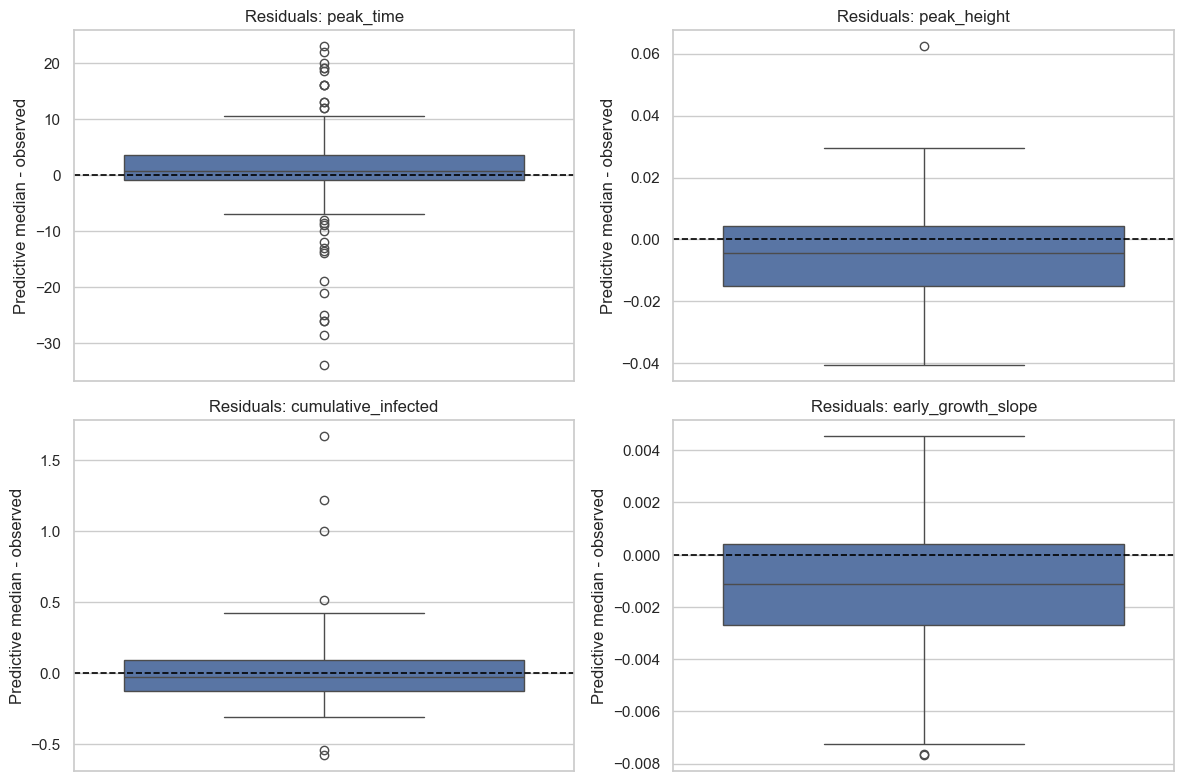

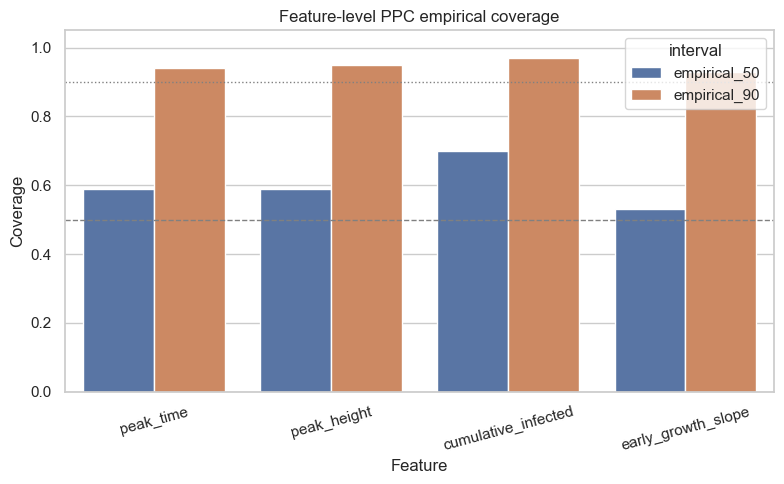

Saved:
  outputs_baseline/E0_matched_ppc_feature_case_level.csv
  outputs_baseline/E0_matched_ppc_feature_summary.csv


In [11]:
def extract_curve_features(curve_1d, time_grid=TIME_GRID, early_days=8):
    """
    Extract simple epidemic features from a 1D infected-fraction curve.
    Returns:
        peak_time, peak_height, cumulative_infected, early_growth_slope
    """
    y = np.asarray(curve_1d).reshape(-1)
    t = np.asarray(time_grid).reshape(-1)

    peak_idx = int(np.argmax(y))
    peak_time = float(t[peak_idx])
    peak_height = float(y[peak_idx])

    # area under curve
    cumulative_infected = float(np.trapz(y, t))

    # early growth slope: linear fit on the first early_days points
    k = min(early_days, len(y))
    x_early = t[:k]
    y_early = y[:k]
    slope = float(np.polyfit(x_early, y_early, deg=1)[0])

    return {
        "peak_time": peak_time,
        "peak_height": peak_height,
        "cumulative_infected": cumulative_infected,
        "early_growth_slope": slope,
    }


def evaluate_feature_level_ppc(
    workflow,
    n_test=50,
    num_posterior_samples=1000,
    n_ppc_draws=100,
    seed=2026,
):
    """
    Evaluate feature-level posterior predictive adequacy on matched test cases.

    For each test case:
      1) simulate one observed noisy curve
      2) sample posterior for beta, gamma
      3) draw posterior parameter samples
      4) re-simulate posterior predictive noisy curves
      5) compare observed features against posterior predictive feature distribution

    Returns:
        feature_case_df: per-case, per-feature results
        feature_summary_df: aggregated PPC summary by feature
    """
    rng = np.random.default_rng(seed)
    rows = []

    for case_id in range(n_test):
        # simulate one matched observed case 
        beta_true = rng.uniform(*PRIOR_BOUNDS["beta"])
        gamma_true = rng.uniform(*PRIOR_BOUNDS["gamma"])
        obs = simulate_curve(beta_true, gamma_true, rng=rng)[:, 0]

        obs_feats = extract_curve_features(obs)

        # posterior sampling
        samples = workflow.sample(
            num_samples=num_posterior_samples,
            conditions={"obs": obs[None, :, None]},
            split=True,
            batch_size=1,
        )

        z_beta_samps = np.asarray(samples["z_beta"]).reshape(-1)
        z_gamma_samps = np.asarray(samples["z_gamma"]).reshape(-1)

        beta_samps = from_unconstrained(z_beta_samps, *PRIOR_BOUNDS["beta"])
        gamma_samps = from_unconstrained(z_gamma_samps, *PRIOR_BOUNDS["gamma"])


        # choose posterior draws for PPC
        draw_idx = rng.choice(len(beta_samps), size=n_ppc_draws, replace=False)
        beta_draws = beta_samps[draw_idx]
        gamma_draws = gamma_samps[draw_idx]

        # posterior predictive curves 
        ppc_feature_rows = {k: [] for k in obs_feats.keys()}

        for b, g in zip(beta_draws, gamma_draws):
            pred_curve = simulate_curve(float(b), float(g), rng=rng)[:, 0]
            pred_feats = extract_curve_features(pred_curve)

            for feat_name, feat_val in pred_feats.items():
                ppc_feature_rows[feat_name].append(feat_val)

        # summarize feature-level PPC for this case 
        for feat_name, obs_val in obs_feats.items():
            pred_vals = np.asarray(ppc_feature_rows[feat_name], dtype=float)

            q25, q50, q75 = np.quantile(pred_vals, [0.25, 0.50, 0.75])
            q05, q95 = np.quantile(pred_vals, [0.05, 0.95])

            rows.append({
                "case_id": case_id,
                "true_beta": float(beta_true),
                "true_gamma": float(gamma_true),
                "true_R0": float(beta_true / gamma_true),
                "feature": feat_name,
                "observed_value": float(obs_val),
                "pred_mean": float(pred_vals.mean()),
                "pred_median": float(q50),
                "pred_std": float(pred_vals.std(ddof=1)),
                "pred_ci50_low": float(q25),
                "pred_ci50_high": float(q75),
                "pred_ci90_low": float(q05),
                "pred_ci90_high": float(q95),
                "pred_width50": float(q75 - q25),
                "pred_width90": float(q95 - q05),
                "covered50": float(q25 <= obs_val <= q75),
                "covered90": float(q05 <= obs_val <= q95),
                "err_mean": float(pred_vals.mean() - obs_val),
                "err_median": float(q50 - obs_val),
                "abs_err_median": float(abs(q50 - obs_val)),
                "sq_err_median": float((q50 - obs_val) ** 2),
            })

    feature_case_df = pd.DataFrame(rows)

    # aggregate summary 
    summary_rows = []
    for feat_name in [
        "peak_time",
        "peak_height",
        "cumulative_infected",
        "early_growth_slope",
    ]:
        sub = feature_case_df[feature_case_df["feature"] == feat_name].copy()

        empirical_50 = sub["covered50"].mean()
        empirical_90 = sub["covered90"].mean()

        summary_rows.append({
            "feature": feat_name,
            "nominal_50": 0.50,
            "empirical_50": empirical_50,
            "diff_50": empirical_50 - 0.50,
            "nominal_90": 0.90,
            "empirical_90": empirical_90,
            "diff_90": empirical_90 - 0.90,
            "bias_mean_pred": sub["err_mean"].mean(),
            "bias_median_pred": sub["err_median"].mean(),
            "MAE_median_pred": sub["abs_err_median"].mean(),
            "RMSE_median_pred": np.sqrt(sub["sq_err_median"].mean()),
            "avg_pred_std": sub["pred_std"].mean(),
            "avg_width50": sub["pred_width50"].mean(),
            "avg_width90": sub["pred_width90"].mean(),
        })

    feature_summary_df = pd.DataFrame(summary_rows)

    return feature_case_df, feature_summary_df



# Run feature-level PPC evaluation
feature_case_df, feature_summary_df = evaluate_feature_level_ppc(
    workflow=workflow,
    n_test=100,                 
    num_posterior_samples=1000,
    n_ppc_draws=100,
    seed=2026,
)

print("\nFeature-level PPC summary:")
display(feature_summary_df.round(4))

print("\nFeature-level PPC case head:")
display(feature_case_df.head().round(4))


# Residual visualization by feature
# residual = posterior predictive median - observed feature
plot_df = feature_case_df.copy()
plot_df["residual"] = plot_df["err_median"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

feature_order = [
    "peak_time",
    "peak_height",
    "cumulative_infected",
    "early_growth_slope",
]

for ax, feat in zip(axes, feature_order):
    sub = plot_df[plot_df["feature"] == feat].copy()
    sns.boxplot(data=sub, y="residual", ax=ax)
    ax.axhline(0.0, color="black", linestyle="--", lw=1.2)
    ax.set_title(f"Residuals: {feat}")
    ax.set_xlabel("")
    ax.set_ylabel("Predictive median - observed")

plt.tight_layout()
plt.show()


# Coverage visualization by feature
cov_plot_df = feature_summary_df.melt(
    id_vars="feature",
    value_vars=["empirical_50", "empirical_90"],
    var_name="interval",
    value_name="coverage",
)

plt.figure(figsize=(8, 5))
sns.barplot(data=cov_plot_df, x="feature", y="coverage", hue="interval")
plt.axhline(0.50, color="gray", linestyle="--", lw=1.0)
plt.axhline(0.90, color="gray", linestyle=":", lw=1.0)
plt.title("Feature-level PPC empirical coverage")
plt.xlabel("Feature")
plt.ylabel("Coverage")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


# save E0 feature-level PPC outputs
feature_case_df.to_csv("outputs_baseline/E0_matched_ppc_feature_case_level.csv", index=False)
feature_summary_df.to_csv("outputs_baseline/E0_matched_ppc_feature_summary.csv", index=False)

print("Saved:")
print("  outputs_baseline/E0_matched_ppc_feature_case_level.csv")
print("  outputs_baseline/E0_matched_ppc_feature_summary.csv")

为了从特征层面检查 posterior predictive adequacy，我们将每条 observed curve 和 posterior predictive replicated curve 分别压缩为四个 summary features：`peak_time`、`peak_height`、`cumulative_infected` 和 `early_growth_slope`。随后，我们在 100 个 matched test cases 上比较 observed features 与 posterior predictive feature distributions，并报告残差分布与 empirical coverage。结果显示，四个 feature 的 90% predictive coverage 均接近或略高于 nominal 0.9，说明 matched baseline 在 feature space 中总体具有良好的 posterior predictive adequacy。50% coverage 也整体接近 nominal 0.5，但多数 feature 略偏高，表明 predictive intervals 略保守。其中，`peak_height` 和 `early_growth_slope` 的残差分布较集中，说明模型能够较稳定地复现峰值高度和早期增长行为；`cumulative_infected` 的 coverage 偏高，说明整体感染负担的不确定性区间稍宽；`peak_time` 的残差分布最分散，这是因为该特征通过 noisy curve 上的 `argmax` 定义，对局部噪声特别敏感，因此应被视为支持性但相对不稳健的 feature-level diagnostic。

## Overall E0 baseline figure

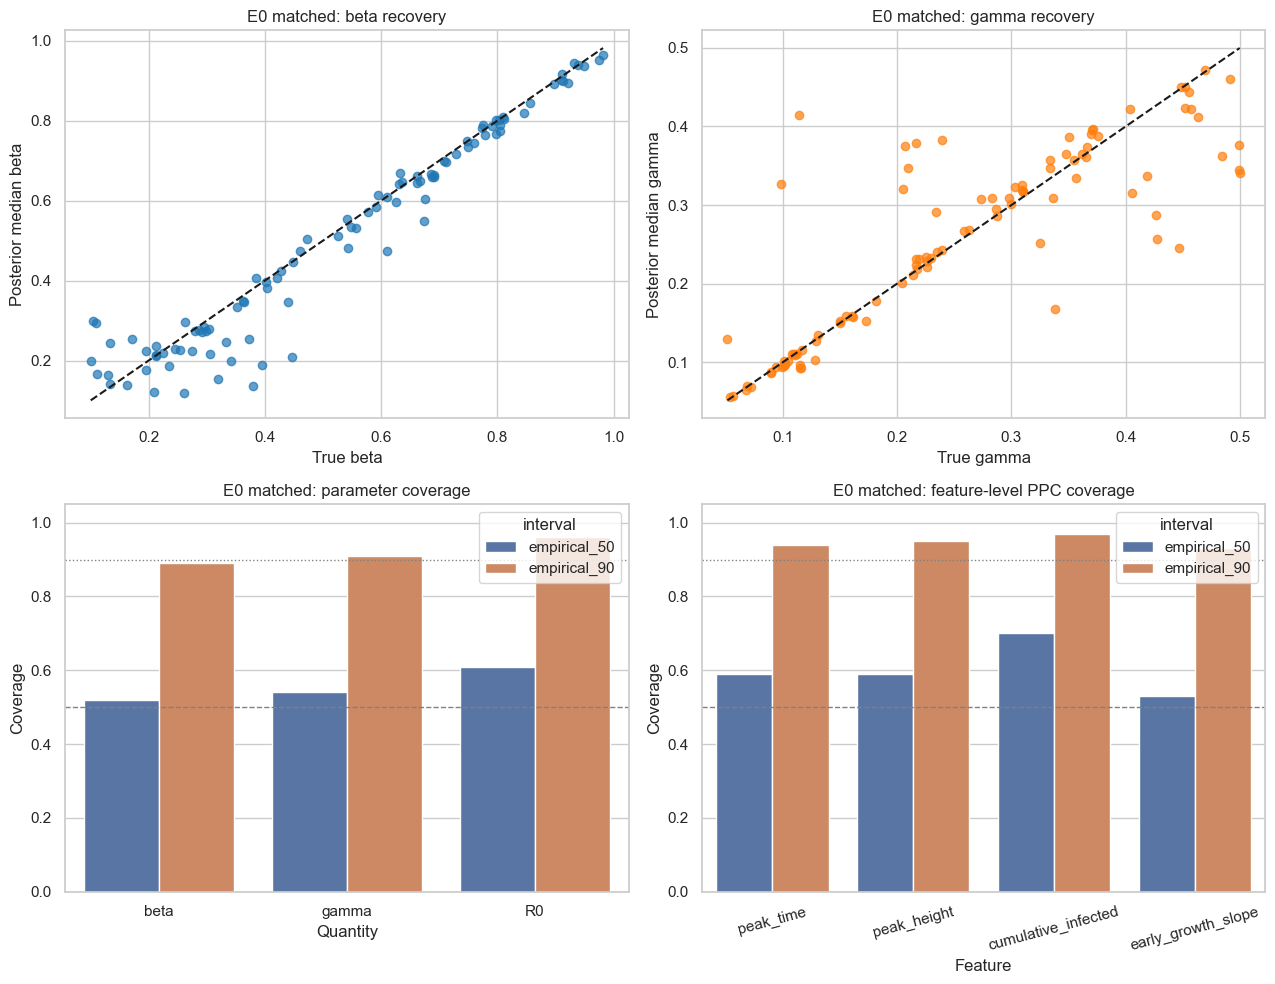

Saved:
  outputs_baseline/E0_matched_overall_baseline_figure.png


In [12]:
# 1) parameter recovery panels use beta / gamma scatter
# 2) parameter coverage panel uses empirical vs nominal
# 3) feature-level PPC coverage panel uses empirical vs nominal

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Panel A: beta recovery
ax = axes[0, 0]
x = case_df["true_beta"]
y = case_df["beta_median"]
ax.scatter(x, y, alpha=0.7, color="#1f77b4")
lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5)
ax.set_xlabel("True beta")
ax.set_ylabel("Posterior median beta")
ax.set_title("E0 matched: beta recovery")

# Panel B: gamma recovery
ax = axes[0, 1]
x = case_df["true_gamma"]
y = case_df["gamma_median"]
ax.scatter(x, y, alpha=0.7, color="#ff7f0e")
lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5)
ax.set_xlabel("True gamma")
ax.set_ylabel("Posterior median gamma")
ax.set_title("E0 matched: gamma recovery")

# Panel C: parameter empirical vs nominal coverage
ax = axes[1, 0]
param_cov_plot = coverage_df.melt(
    id_vars="quantity",
    value_vars=["empirical_50", "empirical_90"],
    var_name="interval",
    value_name="coverage",
)
sns.barplot(data=param_cov_plot, x="quantity", y="coverage", hue="interval", ax=ax)
ax.axhline(0.50, color="gray", linestyle="--", lw=1.0)
ax.axhline(0.90, color="gray", linestyle=":", lw=1.0)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Quantity")
ax.set_ylabel("Coverage")
ax.set_title("E0 matched: parameter coverage")

# Panel D: feature-level PPC empirical vs nominal coverage
ax = axes[1, 1]
feat_cov_plot = feature_summary_df.melt(
    id_vars="feature",
    value_vars=["empirical_50", "empirical_90"],
    var_name="interval",
    value_name="coverage",
)
sns.barplot(data=feat_cov_plot, x="feature", y="coverage", hue="interval", ax=ax)
ax.axhline(0.50, color="gray", linestyle="--", lw=1.0)
ax.axhline(0.90, color="gray", linestyle=":", lw=1.0)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Feature")
ax.set_ylabel("Coverage")
ax.set_title("E0 matched: feature-level PPC coverage")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

fig.savefig("outputs_baseline/E0_matched_overall_baseline_figure.png", dpi=200, bbox_inches="tight")
print("Saved:")
print("  outputs_baseline/E0_matched_overall_baseline_figure.png")

左上图和右上图分别展示 `beta` 与 `gamma` 的 batch-level truth-vs-posterior-median recovery，我们可以看到 `beta` 的恢复整体较稳定，大多数样本贴近对角线，而 `gamma` 的散布更大，表明恢复率在 matched setting 下也比传播率更难识别。左下图展示参数层的 empirical interval coverage，相比 nominal 0.5 与 0.9，`beta`、`gamma` 和 `R0` 的覆盖总体合理，仅存在轻微偏差：`beta` 略有 under-coverage，`R0` 则略显保守。右下图展示 feature-level PPC coverage，结果表明 `peak_time`、`peak_height`、`cumulative_infected` 和 `early_growth_slope` 的 posterior predictive coverage 均接近或略高于 nominal，说明 matched baseline 在 feature space 中也具有良好的 predictive adequacy。整体而言，这张图表明 E0 不仅能恢复参数真值，还能给出大体合理的不确定性区间，并在曲线特征层面复现观测行为，因此E0可以作为后续misspecification 实验的可靠参照baseline。